# Model Evaluation

In [9]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from tensorflow.keras.models import load_model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import os
sns.set_theme(style="darkgrid", context="paper", palette="bright")

In [10]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [11]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
history = pd.read_csv(os.path.join(MODEL_DIR, "history.csv"))

X_test_scaled = np.load(os.path.join(ARTIFACT_DIR, "X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR, "y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR, "encoder.pkl"))

In [12]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax[0],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[0].set_title("Confusion Matrix (Counts)")
    ax[0].set_ylabel("True Label")
    ax[0].set_xlabel("Predicted Label")

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        ax=ax[1],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[1].set_title("Confusion Matrix (Normalized)")
    ax[1].set_ylabel("True Label")
    ax[1].set_xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()

In [13]:
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 17s 626us/step


[[ 22562      0      0    229    243]
 [     2 491802  92848      8      3]
 [     3  95458 126747      9      4]
 [   191      0      4  32452     18]
 [   535      1      1      9  12594]]


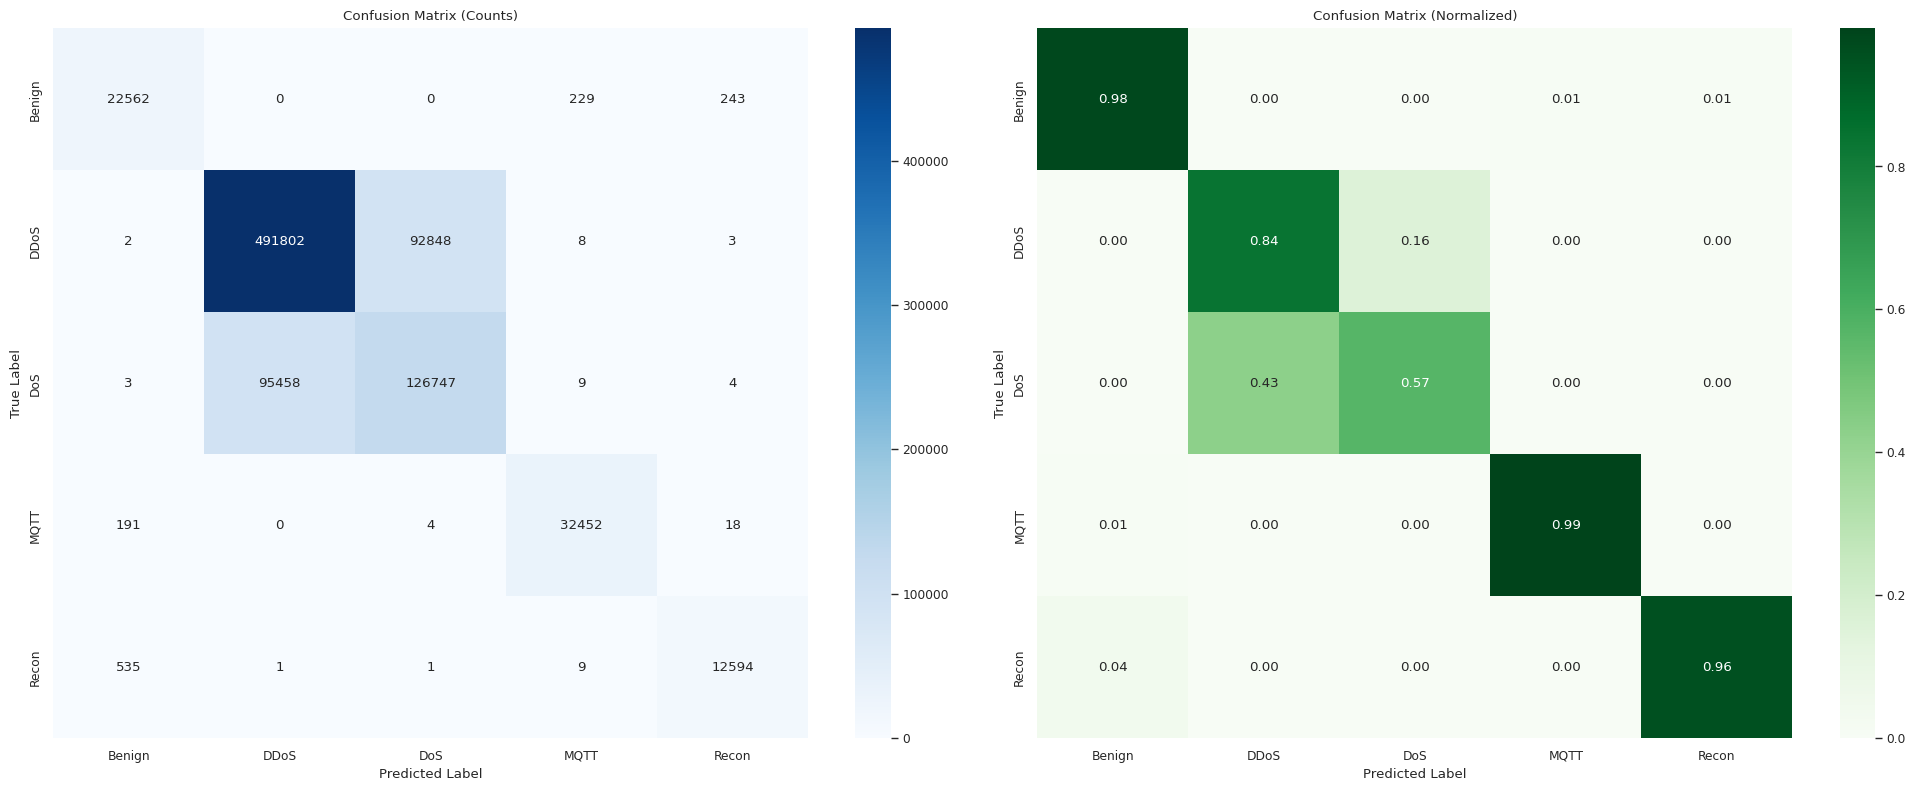

In [14]:
plot_confusion_matrix(y_test, y_pred_classes, encoder.classes_)

In [15]:
print(
    classification_report(
        y_test, y_pred_classes, digits=4, target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      Benign     0.9686    0.9795    0.9740     23034
        DDoS     0.8375    0.8412    0.8393    584663
         DoS     0.5772    0.5704    0.5737    222221
        MQTT     0.9922    0.9935    0.9928     32665
       Recon     0.9792    0.9584    0.9687     13140

    accuracy                         0.7835    875723
   macro avg     0.8709    0.8686    0.8697    875723
weighted avg     0.7828    0.7835    0.7831    875723



In [16]:
f1_score(y_test, y_pred_classes, average="macro")

0.8697246574154495

In [17]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {accuracy:.4f}")

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 21s 758us/step - accuracy: 0.7835 - loss: 0.4531
Test accuracy: 0.7835
